# Ridge Regression (RR) on the MALL 5-min Feature Set


**Purpose:** The purpose of this notebook is to compute the out-of-sample forecast performance of the Ridge Regression (RR) model on the $\mathcal{M}_{\mathrm{ALL}}$ 5-min feature set for the EURO STOXX 50 index over the period 1999--2020, following the methodology of Christensen et al. (2023).

The ridge regression model extends the MHAR specification by augmenting the realized-volatility block with a parsimonious set of macro-financial and cross-market predictors. The final MALL feature set used in this notebook is:

- `RVD`, `RVW`, `RVM`
- `VSTOXX`
- `CISS`
- `logEPU_1m_lag`
- `EURUSD_ret`
- `BRENT_ret`
- `NIKKEI_ret`, `NIKKEI_sq`
- `SP500_ret_lag`, `SP500_sq_lag`
- `M1W`, `M1M`

Prior to estimation, all predictor variables are standardized using the mean and standard deviation computed from the training sample. The ridge penalty parameter is selected by validation-set MSE, and one-day-ahead forecasts are generated in a fixed-length rolling-window framework.

## 1. Loading Data
Loading in data from the `MALL_5min.csv` file.


In [4]:
import pandas as pd
import numpy as np
import os
import time
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge

# Load MALL dataset
file_path = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Cleaned Data Sets/MALL_5min.csv"
MALL = pd.read_csv(file_path, index_col="Date", parse_dates=True)

print(f"Shape: {MALL.shape}")
print(f"Date range: {MALL.index[0].date()} to {MALL.index[-1].date()}")
print(f"NaN values: {MALL.isna().sum().sum()}")
MALL.head()


Shape: (5489, 31)
Date range: 1999-01-05 to 2020-08-06
NaN values: 0


,RVD,RVW,RVM,logRVD,logRVW,logRVM,RVD_pos,RVD_neg,RD_neg,RW_neg,...,BRENT,BRENT_ret,NIKKEI_ret,NIKKEI_sq,SP500_ret_lag,SP500_sq_lag,M1W,M1M,RV_target,logRV_target
Date,,,,,,,,,,,,,,,,,,,,,
1999-01-05,0.000106,0.000089,0.000141,-9.153100,-9.328531,-8.866447,0.000071,0.000035,0.000000,0.000000,...,10.30,-0.060282,-0.013746,0.000189,-0.000920,8.458434e-07,0.087690,0.126206,0.000047,-9.966398
1999-01-06,0.000047,0.000090,0.000132,-9.966398,-9.316927,-8.935760,0.000038,0.000009,0.000000,0.000000,...,10.67,0.035292,0.017657,0.000312,0.013491,1.819949e-04,0.100143,0.187219,0.000237,-8.347779
1999-01-07,0.000237,0.000123,0.000131,-8.347779,-9.004761,-8.938374,0.000110,0.000127,-0.012859,0.000000,...,11.08,0.037706,0.005044,0.000025,0.021899,4.795626e-04,0.078881,0.184020,0.000168,-8.689606
1999-01-08,0.000168,0.000146,0.000114,-8.689606,-8.832472,-9.082830,0.000079,0.000089,-0.005883,0.000000,...,11.70,0.054447,-0.010751,0.000116,-0.002053,4.216638e-06,0.078883,0.165510,0.000282,-8.175339
1999-01-11,0.000282,0.000168,0.000117,-8.175339,-8.692020,-9.056351,0.000067,0.000215,-0.025309,-0.001398,...,12.07,0.031134,-0.001744,0.000003,0.004212,1.774503e-05,0.001055,0.140613,0.000191,-8.565468


## 2. Data Split
### 2.1 Train / Validation / Test Split (70 / 10 / 20)


Following Christensen et al. (2023), we split the sample into a training set (70%), validation set (10%), and test set (20%). The test set is reserved exclusively for out-of-sample evaluation and no estimation or tuning is conducted on it.


In [8]:
# Train / Validation / Test split (70 / 10 / 20)
n = len(MALL)
n_train = int(np.floor(0.70 * n))
n_val   = int(np.floor(0.10 * n))
n_test  = n - n_train - n_val

train_idx = MALL.index[:n_train]
val_idx   = MALL.index[n_train:n_train + n_val]
test_idx  = MALL.index[n_train + n_val:]

print(f"Total observations: {n}")
print(f"\nTrain:      {train_idx[0].date()} to {train_idx[-1].date()} ({n_train} obs, {n_train/n*100:.1f}%)")
print(f"Validation: {val_idx[0].date()} to {val_idx[-1].date()} ({n_val} obs, {n_val/n*100:.1f}%)")
print(f"Test:       {test_idx[0].date()} to {test_idx[-1].date()} ({n_test} obs, {n_test/n*100:.1f}%)")


Total observations: 5489

Train:      1999-01-05 to 2014-02-26 (3842 obs, 70.0%)
Validation: 2014-02-27 to 2016-04-20 (548 obs, 10.0%)
Test:       2016-04-21 to 2020-08-06 (1099 obs, 20.0%)


## 3. Ridge Regression
### 3.1 Model Specification


The ridge regression model extends the baseline HAR specification by introducing an $L_2$-penalty on the slope coefficients while allowing a wider MALL information set to enter the forecasting equation. The model is defined as:

$$
RV_{t+1} = \beta_0 + X_t\beta + \varepsilon_{t+1}
$$

where $X_t$ contains the final MALL feature set used in this notebook. The coefficients are estimated by solving the regularized least squares problem:

$$
\min_{\beta_0,\beta}
\left\{
\sum_{t=1}^{T}
\left(RV_{t+1} - \beta_0 - X_t \beta\right)^2
+ \lambda \sum_{j=1}^{p} \beta_j^2
\right\},
$$

with $\lambda \geq 0$ denoting the ridge penalty parameter that controls the degree of shrinkage applied to the coefficients.


### 3.2 Feature Set Construction
Extracting the dependent and independent variables relevant for the RR model.


In [13]:
# Define target and final MALL feature set
feature_cols = [
    "RVD", "RVW", "RVM",
    "VSTOXX", "CISS", "logEPU_1m_lag",
    "EURUSD_ret", "BRENT_ret",
    "NIKKEI_ret", "NIKKEI_sq",
    "SP500_ret_lag", "SP500_sq_lag",
    "M1W", "M1M"
]

y = MALL["RV_target"].values
X_MALL = MALL[feature_cols].values

# Split into train, validation and test sets
X_train = X_MALL[:n_train]
X_val = X_MALL[n_train:n_train + n_val]
X_test = X_MALL[n_train + n_val:]

y_train = y[:n_train]
y_val = y[n_train:n_train + n_val]
y_test = y[n_train + n_val:]

# Compute standardization parameters from training set only
X_mean = X_train.mean(axis=0)
X_std = X_train.std(axis=0, ddof=0)
X_std = np.where(X_std == 0, 1.0, X_std)

# Standardize each split using training-set parameters
X_train_scaled = (X_train - X_mean) / X_std
X_val_scaled = (X_val - X_mean) / X_std
X_test_scaled = (X_test - X_mean) / X_std

print("Feature set:")
for col in feature_cols:
    print(f"  - {col}")
print(f"\nTraining set:   X={X_train_scaled.shape}, y={y_train.shape}")
print(f"Validation set: X={X_val_scaled.shape}, y={y_val.shape}")
print(f"Test set:       X={X_test_scaled.shape}, y={y_test.shape}")
print("\nStandardization check on training sample:")
print(f"  Mean of first 5 columns: {X_train_scaled.mean(axis=0)[:5].round(6)}")
print(f"  Std of first 5 columns:  {X_train_scaled.std(axis=0)[:5].round(6)}")


Feature set:
  - RVD
  - RVW
  - RVM
  - VSTOXX
  - CISS
  - logEPU_1m_lag
  - EURUSD_ret
  - BRENT_ret
  - NIKKEI_ret
  - NIKKEI_sq
  - SP500_ret_lag
  - SP500_sq_lag
  - M1W
  - M1M

Training set:   X=(3842, 14), y=(3842,)
Validation set: X=(548, 14), y=(548,)
Test set:       X=(1099, 14), y=(1099,)

Standardization check on training sample:
  Mean of first 5 columns: [ 0. -0. -0. -0.  0.]
  Std of first 5 columns:  [1. 1. 1. 1. 1.]


## 5. Ridge Model Specification and Hyperparameter Tuning

Following the paper, we tune the ridge penalty by validation-set MSE. In this thesis implementation, the logarithmic grid is extended beyond the paper's upper bound so that the optimum is not artificially forced onto the boundary when stronger shrinkage is preferred by the EURO STOXX 50 data.


Grid size: 1000
Alpha range: 1.00e-05 to 1.00e+05
Optimal alpha: 6.438857e+03
Validation MSE: 9.067328e-09
Position in grid: 880 / 1000
Optimal alpha is an interior point of the grid.


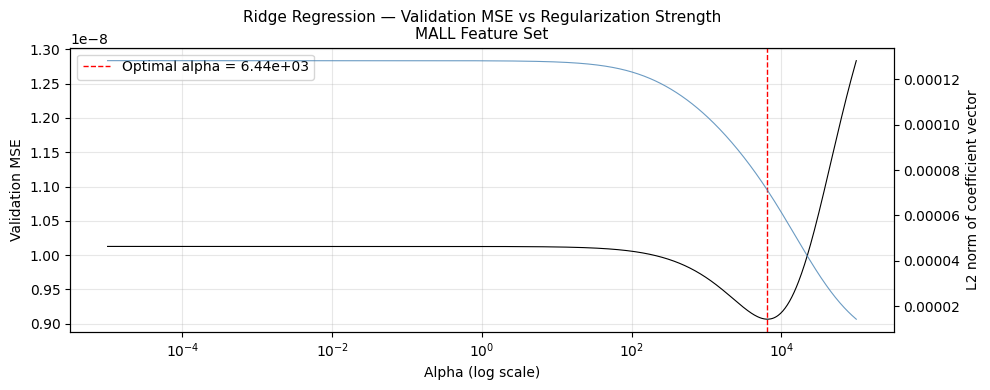

In [16]:
# Define ridge penalty grid following the paper
alpha_grid = np.logspace(-5, 5, 1000)

val_mse = []
coef_norms = []

for alpha in alpha_grid:
    model = Ridge(alpha=alpha, fit_intercept=True)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_val_scaled)
    val_mse.append(np.mean((y_val - y_pred) ** 2))
    coef_norms.append(np.linalg.norm(model.coef_, ord=2))

best_idx = int(np.argmin(val_mse))
optimal_alpha = alpha_grid[best_idx]
optimal_val_mse = val_mse[best_idx]

print(f"Grid size: {len(alpha_grid)}")
print(f"Alpha range: {alpha_grid[0]:.2e} to {alpha_grid[-1]:.2e}")
print(f"Optimal alpha: {optimal_alpha:.6e}")
print(f"Validation MSE: {optimal_val_mse:.6e}")
print(f"Position in grid: {best_idx} / {len(alpha_grid)}")
if best_idx == 0:
    print("Warning: optimum is at the lower boundary.")
elif best_idx == len(alpha_grid) - 1:
    print("Warning: optimum is at the upper boundary.")
else:
    print("Optimal alpha is an interior point of the grid.")

fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.semilogx(alpha_grid, val_mse, color="black", linewidth=0.8)
ax1.axvline(optimal_alpha, color="red", linestyle="--", linewidth=1.0,
            label=f"Optimal alpha = {optimal_alpha:.2e}")
ax1.set_xlabel("Alpha (log scale)")
ax1.set_ylabel("Validation MSE")
ax1.set_title("Ridge Regression — Validation MSE vs Regularization Strength\nMALL Feature Set", fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.legend(loc="upper left")

ax2 = ax1.twinx()
ax2.semilogx(alpha_grid, coef_norms, color="steelblue", linewidth=0.8, alpha=0.8)
ax2.set_ylabel("L2 norm of coefficient vector")
plt.tight_layout()
plt.show()


## 6. Rolling Window Estimation and Forecasting

We now conduct a fixed-length rolling one-step-ahead forecast exercise. For each forecast origin, the training and validation windows retain their original lengths, roll forward one day at a time, and the ridge penalty is re-tuned on the rolling validation sample.


In [19]:
# Rolling ridge forecasts following the paper's regularized-model logic:
# no concatenation of training and validation sets

alpha_grid = np.logspace(-5, 5, 1000)

forecasts_RR = []
dates_test = []
coef_norm_path = []
alpha_path = []

start_time = time.time()

window_size = n_train + n_val

for i in range(n_test):
    # Fixed-length rolling window with constant training and validation spans
    X_window = X_MALL[i:i + window_size]
    y_window = y[i:i + window_size]

    X_train_roll = X_window[:n_train]
    y_train_roll = y_window[:n_train]

    X_val_roll = X_window[n_train:]
    y_val_roll = y_window[n_train:]

    X_test_point = X_MALL[i + window_size].reshape(1, -1)

    # Standardize using the rolling training sample only
    X_mean_roll = X_train_roll.mean(axis=0)
    X_std_roll = X_train_roll.std(axis=0, ddof=0)
    X_std_roll = np.where(X_std_roll == 0, 1.0, X_std_roll)

    X_train_roll_scaled = (X_train_roll - X_mean_roll) / X_std_roll
    X_val_roll_scaled = (X_val_roll - X_mean_roll) / X_std_roll
    X_test_point_scaled = (X_test_point - X_mean_roll) / X_std_roll

    # Tune alpha on the rolling validation set
    val_mse_roll = []

    for alpha in alpha_grid:
        model = Ridge(alpha=alpha, fit_intercept=True)
        model.fit(X_train_roll_scaled, y_train_roll)
        y_val_pred = model.predict(X_val_roll_scaled)
        val_mse_roll.append(np.mean((y_val_roll - y_val_pred) ** 2))

    best_idx = int(np.argmin(val_mse_roll))
    alpha_star = alpha_grid[best_idx]

    # Refit on the rolling training sample and forecast one day ahead
    model_final = Ridge(alpha=alpha_star, fit_intercept=True)
    model_final.fit(X_train_roll_scaled, y_train_roll)
    forecast = model_final.predict(X_test_point_scaled)[0]

    # Paper-consistent floor for negative forecasts
    min_rv_roll = y_train_roll.min()
    forecast = max(forecast, min_rv_roll)

    forecasts_RR.append(forecast)
    dates_test.append(MALL.index[i + window_size])
    coef_norm_path.append(np.linalg.norm(model_final.coef_, ord=2))
    alpha_path.append(alpha_star)

    if (i + 1) % 100 == 0:
        elapsed = (time.time() - start_time) / 60
        print(f"  Day {i + 1:4d}/{n_test} | Date: {MALL.index[i + window_size].date()} | Elapsed: {elapsed:.1f} min")

total_elapsed = (time.time() - start_time) / 60
print(f"\nTotal estimation time: {total_elapsed:.1f} minutes")
print(f"Forecasts generated: {len(forecasts_RR)}")
print(f"Forecast period: {dates_test[0].date()} to {dates_test[-1].date()}")
print(f"Average coefficient L2 norm: {np.mean(coef_norm_path):.6f}")
print(f"Average chosen alpha: {np.mean(alpha_path):.6e}")
alpha_series = pd.Series(alpha_path)
print(f"Boundary hits (min): {(alpha_series <= alpha_grid[0] * 1.001).sum()}")
print(f"Boundary hits (max): {(alpha_series >= alpha_grid[-1] * 0.999).sum()}")


  Day  100/1099 | Date: 2016-09-08 | Elapsed: 0.6 min
  Day  200/1099 | Date: 2017-01-27 | Elapsed: 1.3 min
  Day  300/1099 | Date: 2017-06-21 | Elapsed: 1.9 min
  Day  400/1099 | Date: 2017-11-08 | Elapsed: 2.5 min
  Day  500/1099 | Date: 2018-04-04 | Elapsed: 3.2 min
  Day  600/1099 | Date: 2018-08-22 | Elapsed: 3.8 min
  Day  700/1099 | Date: 2019-01-14 | Elapsed: 4.5 min
  Day  800/1099 | Date: 2019-06-06 | Elapsed: 5.2 min
  Day  900/1099 | Date: 2019-10-24 | Elapsed: 5.8 min
  Day 1000/1099 | Date: 2020-03-17 | Elapsed: 6.5 min

Total estimation time: 7.2 minutes
Forecasts generated: 1099
Forecast period: 2016-04-21 to 2020-08-06
Average coefficient L2 norm: 0.000074
Average chosen alpha: 7.837521e+03
Boundary hits (min): 103
Boundary hits (max): 0


### 3.4.1 Save Forecasts 


In [22]:
import os

# --- Define paths ---
forecast_path = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Cleaned Data Sets/Forecasts 5-min/MALL/Regularized Linear Models"
mse_path = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Cleaned Data Sets/MSE 5-min/MALL/Regularized Linear Models"

os.makedirs(forecast_path, exist_ok=True)
os.makedirs(mse_path, exist_ok=True)

# --- Construct results dataframe ---
results_RR = pd.DataFrame({
    "RV_actual": y_test,
    "RV_forecast": forecasts_RR
}, index=dates_test)

# --- Compute errors ---
errors_RR = results_RR["RV_actual"] - results_RR["RV_forecast"]
mse_RR = np.mean(errors_RR ** 2)

# --- Save forecasts ---
results_RR.to_csv(os.path.join(forecast_path, "forecasts_RR.csv"))

# --- Save MSE summary ---
mse_summary_RR = pd.DataFrame({
    "Model": ["RR"],
    "MSE": [mse_RR],
    "RMSE": [np.sqrt(mse_RR)],
    "MAE": [errors_RR.abs().mean()],
    "Mean_Error": [errors_RR.mean()]
}).set_index("Model")

mse_summary_RR.to_csv(os.path.join(mse_path, "mse_summary_RR.csv"))

# --- Print summary ---
print(f"Forecasts saved to: {forecast_path}")
print(f"MSE summary saved to: {mse_path}")
print(f"Rows saved: {len(results_RR)}")
print(f"Ridge test-set MSE: {mse_RR:.6e}")


Forecasts saved to: /Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Cleaned Data Sets/Forecasts 5-min/MALL/Regularized Linear Models
MSE summary saved to: /Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Cleaned Data Sets/MSE 5-min/MALL/Regularized Linear Models
Rows saved: 1099
Ridge test-set MSE: 5.207367e-08


## 4. Results
### 4.1 Forecast Visualization

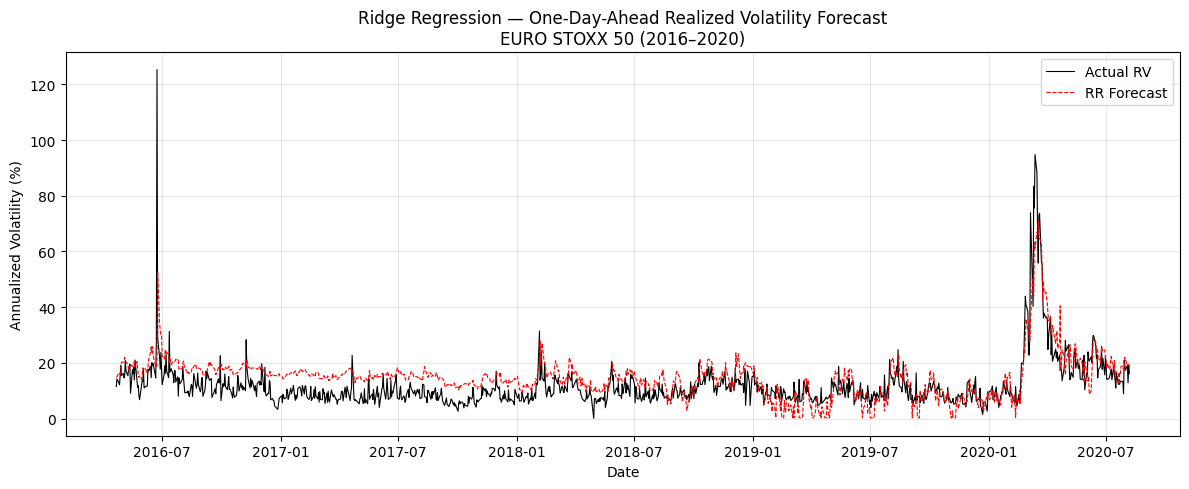


Summary of forecast errors:
Mean error:  -2.339699e-05
RMSE:        2.281966e-04
MAE:         6.544250e-05


In [26]:
import matplotlib.pyplot as plt

# Convert to annualized volatility for readability
results_plot = pd.DataFrame({
    "Actual": np.sqrt(results_RR["RV_actual"] * 252) * 100,
    "Forecast": np.sqrt(results_RR["RV_forecast"] * 252) * 100
}, index=results_RR.index)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(results_plot["Actual"], label="Actual RV", color="black", linewidth=0.8)
ax.plot(results_plot["Forecast"], label="RR Forecast", color="red", linewidth=0.8, linestyle="--")
ax.set_title("Ridge Regression — One-Day-Ahead Realized Volatility Forecast\nEURO STOXX 50 (2016–2020)", fontsize=12)
ax.set_ylabel("Annualized Volatility (%)")
ax.set_xlabel("Date")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nSummary of forecast errors:")
errors = results_RR["RV_actual"] - results_RR["RV_forecast"]
print(f"Mean error:  {errors.mean():.6e}")
print(f"RMSE:        {np.sqrt(mse_RR):.6e}")
print(f"MAE:         {errors.abs().mean():.6e}")
